# Exploratory Data Analysis (EDA)
In this notebook, we explore the HPC traces dataset.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import sys
import os

# Add src to path
sys.path.append('../src')
from data import load_raw_traces

df = load_raw_traces('../../trace.csv')


## Basic Statistics
Print shape, column names, and summary statistics.

In [2]:
print(f'Shape: {df.shape}')
print('\nData Types:')
print(df.dtypes)
print('\nSummary Statistics:')
display(df.describe())


Shape: (800, 3)

Data Types:
cache-references    float64
cycles              float64
LLC-loads           float64
dtype: object

Summary Statistics:


,cache-references,cycles,LLC-loads
count,8.000000e+02,8.000000e+02,8.000000e+02
mean,1.823841e+08,4.772175e+09,6.592874e+06
std,4.999131e+06,2.647226e+07,2.475291e+05
min,1.678617e+08,4.699495e+09,5.915575e+06
25%,1.787137e+08,4.755603e+09,6.402678e+06
50%,1.839196e+08,4.772836e+09,6.656922e+06
75%,1.862454e+08,4.787770e+09,6.776620e+06
max,1.915746e+08,4.996349e+09,7.108173e+06


## Data Quality
Check for missing or invalid values.

In [3]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')


Missing values per column:
cache-references    0
cycles              0
LLC-loads           0
dtype: int64

Duplicates: 0


## Distributions
Histograms and boxplots for each HPC column.

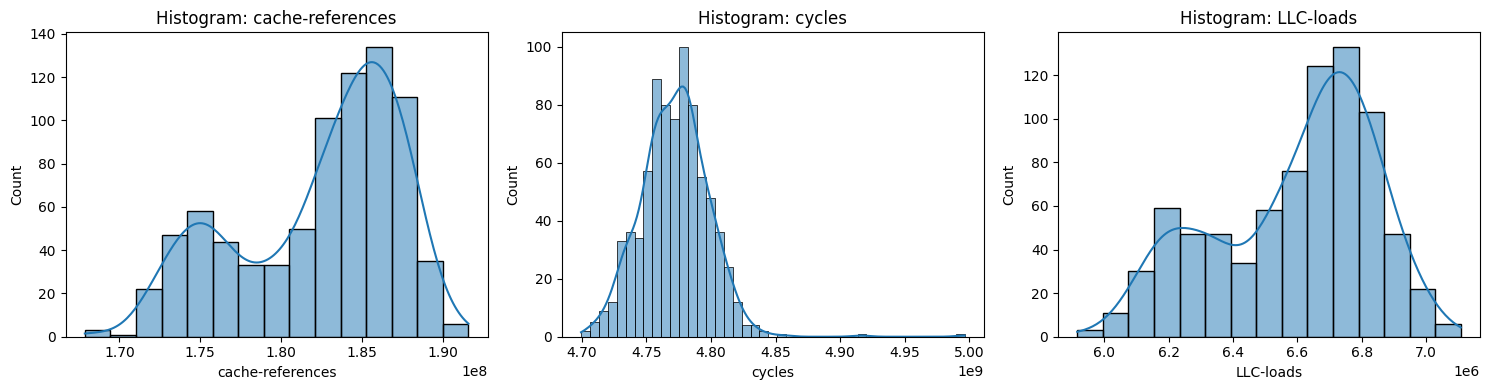

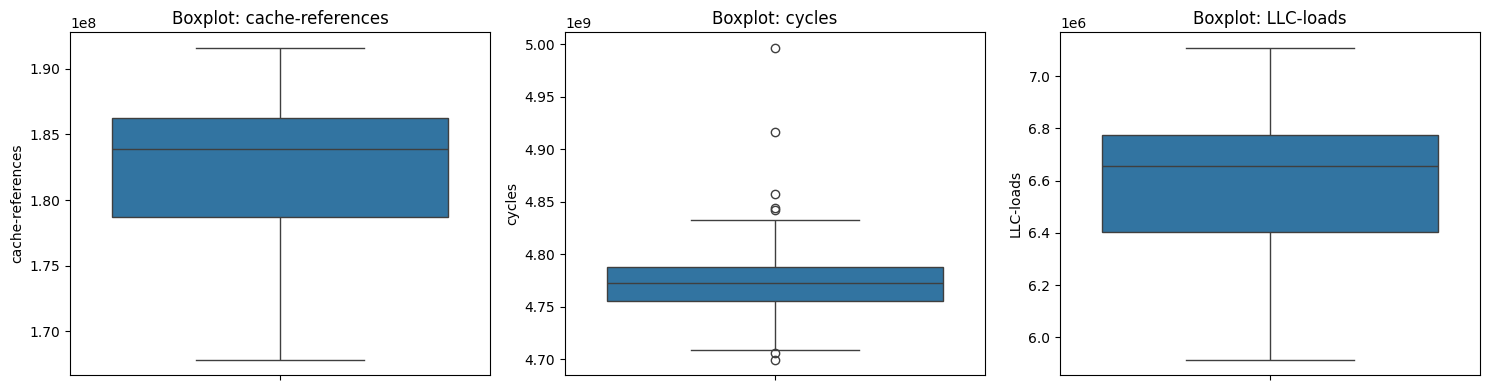

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(df.columns):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Histogram: {col}')
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(df.columns):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()


## Correlation
Heatmap to identify highly correlated features.

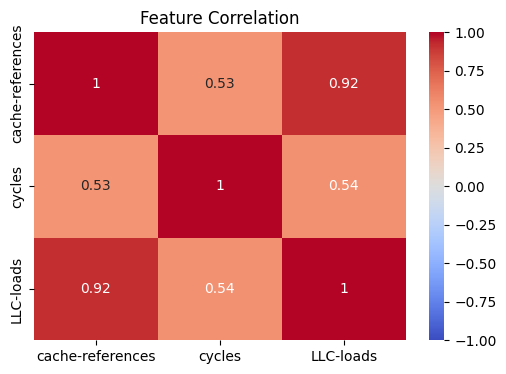

In [5]:
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation')
plt.show()


## Dimensionality Reduction (PCA & t-SNE)
Visualize the clean-trace manifold.

PCA Explained Variance: [0.78145312 0.19178564]


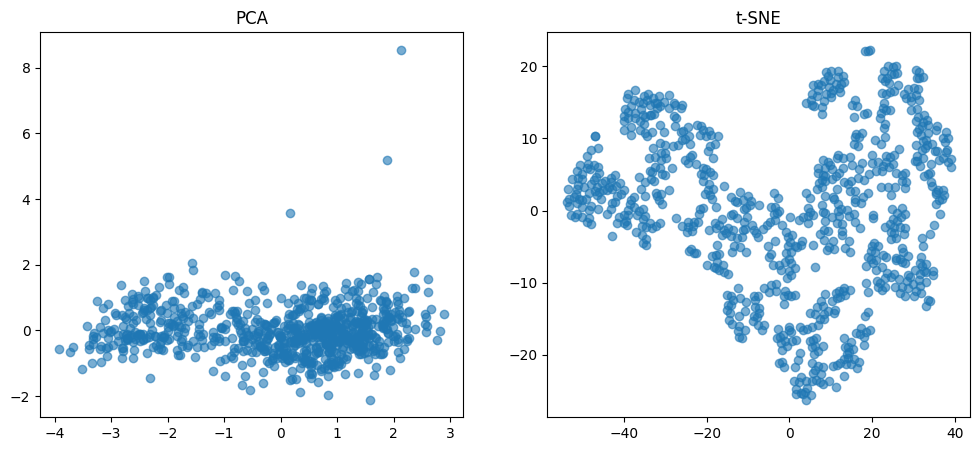

In [6]:
# Standardize first
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
print(f'PCA Explained Variance: {pca.explained_variance_ratio_}')

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.6)
axes[0].set_title('PCA')
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], alpha=0.6)
axes[1].set_title('t-SNE')
plt.show()
